In [74]:
import pandas as pd
import numpy as np

df_vendas = pd.read_csv("vendas_tech.csv",  low_memory=False)
display(df_vendas)
df_gerentes = pd.read_excel("gerentes_lojas.xlsx")
display(df_gerentes)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


,Loja,Gerente,Meta_Mensal
0,São Paulo,Carlos,50000
1,Rio de Janeiro,Fernanda,60000
2,Curitiba,Roberto,45000
3,Belo Horizonte,Juliana,55000
4,Recife,Marcos,48000
5,Porto Alegre,Pedro,42000
6,Salvador,Ana,52000


In [75]:
# INSPECAO
display(df_vendas)
#display(df_vendas.head(15))
#display(df_vendas.tail(15))
#display(df_vendas.sample(15))
display(df_vendas.shape)
display(list(df_vendas.columns))
display(df_vendas.info())
display(df_vendas.describe())

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


(100100, 8)

['ID_Pedido',
 'Data',
 'Loja',
 'Produto',
 'Preco_Unitario',
 'Qtd',
 'Cliente',
 'Data_Base']

<class 'pandas.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  str    
 2   Loja            98099 non-null   str    
 3   Produto         100100 non-null  str    
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  str    
 7   Data_Base       1 non-null       str    
dtypes: float64(1), int64(2), str(5)
memory usage: 6.1 MB


None

,ID_Pedido,Preco_Unitario,Qtd
count,100100.000000,100100.000000,100100.000000
mean,50004.810180,2000.204595,1.499101
std,28866.872543,1841.050733,1.241605
min,1.000000,40.000000,1.000000
25%,25008.750000,120.000000,1.000000
50%,50004.500000,1200.000000,1.000000
75%,75002.250000,3200.000000,1.000000
max,100000.000000,5500.000000,10.000000


In [76]:
# TRATAMENTO DE DADOS
display(df_vendas["Loja"]) # selecionar uma colouna
display(df_vendas[["Loja", "Cliente"]])

# colunas
df_analise = df_vendas.drop(columns=["Data_Base"]) # apaga UMA coluna

# nulos
#df_analise = df_analise.dropna() # apaga as linhas com alguma informacao nula
df_analise["Loja"] = df_analise["Loja"].fillna("Online")

# tipos de dados
df_analise["Data"] = pd.to_datetime(df_analise["Data"], format = "%Y-%m-%d")

# padronizacao
df_analise["Loja"] = df_analise["Loja"].str.strip()
df_analise["Loja"] = df_analise["Loja"].str.title()

#duplicatas
df_analise = df_analise.drop_duplicates(subset=["ID_Pedido", "Loja"], keep="first")

display(df_analise)
display(df_analise.info())

0              São Paulo
1         Belo Horizonte
2                    NaN
3         RIO DE JANEIRO
4         Rio de Janeiro
               ...      
100095      Porto Alegre
100096      Porto Alegre
100097    Belo Horizonte
100098          Salvador
100099        São Paulo 
Name: Loja, Length: 100100, dtype: str

,Loja,Cliente
0,São Paulo,Cliente_4095
1,Belo Horizonte,Cliente_8750
2,NaN,Cliente_14859
3,RIO DE JANEIRO,Cliente_17343
4,Rio de Janeiro,Cliente_23377
...,...,...
100095,Porto Alegre,Cliente_11755
100096,Porto Alegre,Cliente_12879
100097,Belo Horizonte,Cliente_8160
100098,Salvador,Cliente_28545


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[us]
 2   Loja            100000 non-null  str           
 3   Produto         100000 non-null  str           
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 5.3 MB


None

In [77]:
# CRIAR NOVAS COLUNAS

# faturamento
df_analise["Faturamento"] = df_analise["Qtd"] * df_analise["Preco_Unitario"]

# regiao (sul, sudeste, nordeste etc)
display(df_analise["Loja"].unique())

dic_regioes = {
  "São Paulo": "Sudeste", 
  "Belo Horizonte": "Sudeste",         
  "Online": "Online", 
  "Rio De Janeiro": "Sudeste",
  "Salvador": "Nordeste",         
  "Recife": "Nordeste",       
  "Curitiba": "Sul",   
  "Porto Alegre": "Sul"
}
df_analise["Região"] = df_analise["Loja"].map(dic_regioes)

# forma de venda (presencial/online)
df_analise["Forma_de_Venda"] = np.where(df_analise["Loja"] == "Online", "Online", "Presencial")

display(df_analise)
display(df_analise.isna().sum()) # verifica se tem algum valor vazio em cada coluna

<StringArray>
[     'São Paulo', 'Belo Horizonte',         'Online', 'Rio De Janeiro',
       'Salvador',         'Recife',       'Curitiba',   'Porto Alegre']
Length: 8, dtype: str

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Região,Forma_de_Venda
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Sudeste,Presencial
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0,Sudeste,Presencial
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,Online,Online
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Sudeste,Presencial
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Sudeste,Presencial
...,...,...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0,Sudeste,Presencial
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058,40.0,Sudeste,Presencial
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0,Sul,Presencial
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205,5500.0,Sul,Presencial


ID_Pedido         0
Data              0
Loja              0
Produto           0
Preco_Unitario    0
Qtd               0
Cliente           0
Faturamento       0
Região            0
Forma_de_Venda    0
dtype: int64

In [78]:
# ANALISAR -> filtrar a base de dados

df_analise = df_analise.sort_values(by=["Data", "Faturamento"])
df_analise = df_analise.reset_index(drop=True)
#.loc: id do pedido -> por nome da coluna e nome da linha
id_pedido = 4

loja = df_analise.loc[df_analise["ID_Pedido"]==4, "Loja"].values[0]
produto = df_analise.loc[df_analise["ID_Pedido"]==4, "Produto"].values[0]
cliente = df_analise.loc[df_analise["ID_Pedido"]==4, "Cliente"].values[0]
print(loja, produto, cliente)

#.iloc -> por posicao
loja = df_analise.iloc[3, 2]
produto = df_analise.iloc[3, 3]
cliente = df_analise.iloc[3, 6]
print(loja, produto, cliente)

#condicional
df_id_pedido = df_analise[df_analise["ID_Pedido"]==4]

# exportar pedacos da base
df_vendas_sp = df_analise[df_analise["Loja"]=="São Paulo"]
df_vendas_sp.to_csv("Vendas_SP.csv", index=False)

# exportar vendas 2024
df_vendas_2024 = df_analise[df_analise["Data"].dt.year==2024]

# duplas condicionais
condicao = df_analise["Produto"] == "Cabo HDMI"
condicao2 = df_analise["Região"] == "Sul"
df_vendas_HDMI_sul = df_vendas_2024[condicao & condicao2]

display(df_vendas_HDMI_sul)
display(df_vendas_2024.info())

Rio De Janeiro Mouse Gamer Cliente_17343
Porto Alegre Cabo HDMI Cliente_22886


C:\Users\eduar\AppData\Local\Temp\ipykernel_18320\2096133399.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_vendas_HDMI_sul = df_vendas_2024[condicao & condicao2]


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Região,Forma_de_Venda
50424,31751,2024-01-01,Curitiba,Cabo HDMI,40.0,1,Cliente_16439,40.0,Sul,Presencial
50426,44184,2024-01-01,Curitiba,Cabo HDMI,40.0,1,Cliente_1577,40.0,Sul,Presencial
50427,44259,2024-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_1944,40.0,Sul,Presencial
50428,46104,2024-01-01,Curitiba,Cabo HDMI,40.0,1,Cliente_29811,40.0,Sul,Presencial
50431,54222,2024-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_2708,40.0,Sul,Presencial
...,...,...,...,...,...,...,...,...,...,...
99874,75695,2024-12-30,Porto Alegre,Cabo HDMI,40.0,1,Cliente_29587,40.0,Sul,Presencial
99875,78584,2024-12-30,Curitiba,Cabo HDMI,40.0,1,Cliente_21307,40.0,Sul,Presencial
99880,35127,2024-12-30,Curitiba,Cabo HDMI,40.0,2,Cliente_20687,80.0,Sul,Presencial
99881,47774,2024-12-30,Porto Alegre,Cabo HDMI,40.0,2,Cliente_14363,80.0,Sul,Presencial


<class 'pandas.DataFrame'>
RangeIndex: 49577 entries, 50423 to 99999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       49577 non-null  int64         
 1   Data            49577 non-null  datetime64[us]
 2   Loja            49577 non-null  str           
 3   Produto         49577 non-null  str           
 4   Preco_Unitario  49577 non-null  float64       
 5   Qtd             49577 non-null  int64         
 6   Cliente         49577 non-null  str           
 7   Faturamento     49577 non-null  float64       
 8   Região          49577 non-null  str           
 9   Forma_de_Venda  49577 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(2), str(5)
memory usage: 3.8 MB


None

In [79]:
# analises por agrupamento
analise_lojas = df_analise[["Loja", "Faturamento"]].groupby("Loja").sum() # Escolhe as colunas com que vai trabalhar
analise_lojas = analise_lojas.sort_values(by="Faturamento", ascending=False) # Organiza por ordem decrescente de faturamento
analise_lojas = analise_lojas.reset_index() # Adiciona um novo indice
analise_lojas["Faturamento"] = analise_lojas["Faturamento"].map("R${:,.2f}".format) # Coloca o faturamento em formato de dinheiro (REAL)

display(analise_lojas)

# Ranking de produtos que mais venderam no online
df_vendas_online = df_analise[df_analise["Loja"]=="Online"] # Mostra apenas infos da loja ONLINE
analise_produtos_online = df_vendas_online[["Produto", "Qtd"]].groupby("Produto").sum()
analise_produtos_online = analise_produtos_online.sort_values(by="Qtd", ascending=False)
analise_produtos_online = analise_produtos_online.reset_index()
analise_produtos_online = analise_produtos_online.rename(columns={"Qtd": "Vendas totais"}) # Renomear o nome de uma coluna

display(df_vendas_online)
display(analise_produtos_online)

# Ranking por loja e produto ao mesmo tempo
# Quais produtos vendeu mais em cada loja
analise_produtos_lojas = df_analise[["Loja", "Produto", "Qtd"]].groupby(["Loja", "Produto"]).sum()

#analise_produtos_lojas = analise_produtos_lojas.sort_values(by="Qtd", ascending=False)

with pd.option_context("display.max_rows", None): # Apresenta a tabela inteira
    display(analise_produtos_lojas)

# Quais lojas mais venderam o produto
analise_lojas_produto = df_analise[["Loja", "Produto", "Qtd"]].groupby(["Produto", "Loja"]).sum()

#analise_lojas_produto = analise_lojas_produto.sort_values(by="Qtd", ascending=False)

display(analise_lojas_produto)


,Loja,Faturamento
0,Salvador,"R$42,300,610.00"
1,Rio De Janeiro,"R$42,294,720.00"
2,Recife,"R$42,190,390.00"
3,São Paulo,"R$42,090,690.00"
4,Belo Horizonte,"R$41,714,890.00"
5,Porto Alegre,"R$41,678,460.00"
6,Curitiba,"R$41,121,720.00"
7,Online,"R$6,080,850.00"


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Região,Forma_de_Venda
58,71409,2023-01-01,Online,Smartphone Samsung,2200.0,1,Cliente_13248,2200.0,Online,Online
76,42190,2023-01-01,Online,Notebook Dell,3500.0,1,Cliente_20957,3500.0,Online,Online
240,81764,2023-01-02,Online,Notebook Dell,3500.0,1,Cliente_9372,3500.0,Online,Online
268,84361,2023-01-02,Online,Notebook HP,3200.0,2,Cliente_16773,6400.0,Online,Online
284,37480,2023-01-02,Online,Notebook HP,3200.0,5,Cliente_1678,16000.0,Online,Online
...,...,...,...,...,...,...,...,...,...,...
99860,95096,2024-12-29,Online,iPhone 14,5500.0,1,Cliente_25495,5500.0,Online,Online
99900,55643,2024-12-30,Online,Mouse Gamer,120.0,2,Cliente_20362,240.0,Online,Online
99930,8028,2024-12-30,Online,Smartphone Samsung,2200.0,1,Cliente_20679,2200.0,Online,Online
99952,38943,2024-12-30,Online,Notebook HP,3200.0,1,Cliente_18490,3200.0,Online,Online


,Produto,Vendas totais
0,Notebook HP,442
1,Cabo HDMI,403
2,iPhone 14,390
3,Mouse Gamer,379
4,Notebook Dell,369
5,Teclado Mecânico,343
6,"Monitor 27""",332
7,Smartphone Samsung,311


Qtd
Loja           Produto                 
Belo Horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
               Smartphone Samsung  2597
               Teclado Mecânico    2609
               iPhone 14           2478
Curitiba       Cabo HDMI           2698
               Monitor 27"         2626
               Mouse Gamer         2600
               Notebook Dell       2517
               Notebook HP         2529
               Smartphone Samsung  2444
               Teclado Mecânico    2742
               iPhone 14           2652
Online         Cabo HDMI            403
               Monitor 27"          332
               Mouse Gamer          379
               Notebook Dell        369
               Notebook HP          442
               Smartphone Samsung   311
               Teclado Mecânico     343
               iPhone 14            390
Porto Alegre   Cabo HDMI           2571
               Monitor 27"         2655
               Mouse Gamer         2611
               Notebook Dell       2770
               Notebook HP         2511
               Smartphone Samsung  2603
               Teclado Mecânico    2598
               iPhone 14           2540
Recife         Cabo HDMI           2534
               Monitor 27"         2647
               Mouse Gamer         2639
               Notebook Dell       2566
               Notebook HP         2651
               Smartphone Samsung  2660
               Teclado Mecânico    2775
               iPhone 14           2652
Rio De Janeiro Cabo HDMI           2747
               Monitor 27"         2798
               Mouse Gamer         2652
               Notebook Dell       2534
               Notebook HP         2614
               Smartphone Samsung  2626
               Teclado Mecânico    2548
               iPhone 14           2702
Salvador       Cabo HDMI           2566
               Monitor 27"         2545
               Mouse Gamer         2711
               Notebook Dell       2512
               Notebook HP         2785
               Smartphone Samsung  2627
               Teclado Mecânico    2579
               iPhone 14           2671
São Paulo      Cabo HDMI           2649
               Monitor 27"         2796
               Mouse Gamer         2714
               Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

Qtd
Produto   Loja                
Cabo HDMI Belo Horizonte  2636
          Curitiba        2698
          Online           403
          Porto Alegre    2571
          Recife          2534
...                        ...
iPhone 14 Porto Alegre    2540
          Recife          2652
          Rio De Janeiro  2702
          Salvador        2671
          São Paulo       2735

[64 rows x 1 columns]

In [80]:
# Quais gerentes bateram a meta de janeiro 2023

df_meta = df_analise[(df_analise["Data"].dt.year==2023) & (df_analise["Data"].dt.month==1)]
df_meta = df_meta[["Loja", "Faturamento"]].groupby("Loja", as_index=False).sum()
#df_meta = pd.concat([tabela1, tabela2]) para juntar uma tabela a outra
df_gerentes["Loja"] = df_gerentes["Loja"].str.strip()
df_gerentes["Loja"] = df_gerentes["Loja"].str.title()
df_meta = df_meta.merge(df_gerentes, on="Loja", how="left") # Padrao: INNER join
condicao = df_meta["Faturamento"] >= df_meta["Meta_Mensal"] # Verifica se bateu a meta
df_meta["Bateu Meta"] = np.where(condicao, "Sim", "Não")
#df_meta = df_meta.merge(df_gerentes, left_on="Loja", right_on="Cidade") caso as tabelas correspondentes tenham nome DIFERENTES

display(df_meta)

,Loja,Faturamento,Gerente,Meta_Mensal,Bateu Meta
0,Belo Horizonte,1779100.0,Juliana,55000.0,Sim
1,Curitiba,1986920.0,Roberto,45000.0,Sim
2,Online,404570.0,NaN,NaN,Não
3,Porto Alegre,1726640.0,Pedro,42000.0,Sim
4,Recife,1779020.0,Marcos,48000.0,Sim
5,Rio De Janeiro,1736830.0,Fernanda,60000.0,Sim
6,Salvador,1686070.0,Ana,52000.0,Sim
7,São Paulo,1831140.0,Carlos,50000.0,Sim


,Faturamento
Mes_Ano,
2023-01,12930290.0
2023-02,11515150.0
2023-03,12516080.0
2023-04,12528900.0
2023-05,12940470.0
2023-06,12455820.0
2023-07,12550990.0
2023-08,12989130.0
2023-09,12118180.0


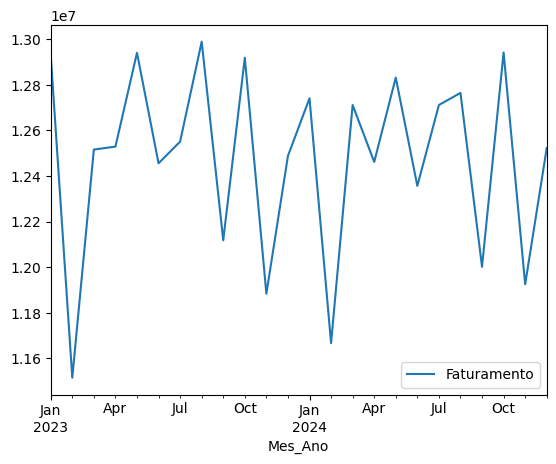

In [81]:

df_analise["Mes_Ano"] = df_analise["Data"].dt.to_period("M")
df_vendas_mes = df_analise[["Mes_Ano", "Faturamento"]].groupby("Mes_Ano").sum()
df_vendas_mes.plot()
display(df_vendas_mes)

In [82]:
# DESAFIOS (fixar alguns conceitos)

# Simulando duas tabelas que a empresa te enviou
dados_clientes = pd.DataFrame({
    "ID_Cliente": [1, 2, 3, 4],
    "Nome": ["Ana", "Bruno", "Carlos", "Daniela"],
    "Cidade": ["RIO DE JANEIRO", "são paulo", "Rio de Janeiro", "Belo Horizonte"]
})

dados_compras = pd.DataFrame({
    "ID_Compra": [101, 102, 103, 104],
    "ID_Cliente": [1, 2, 1, 4], 
    "Valor_Compra": [250.0, 150.0, 300.0, 400.0]
})
# Corrigir a formatacao dos textos
dados_clientes["Cidade"]= dados_clientes["Cidade"].str.strip()
dados_clientes["Cidade"] = dados_clientes["Cidade"].str.title()

# Juntar uma coluna na outra atraves do ID_ Cliente
dados_clientes_modificada =  dados_clientes.merge(dados_compras, left_on="ID_Cliente", right_on="ID_Cliente")

# Qual cidade gerou mais dinheiro (Valor_Compra) no total?
Cidade_Mais_Vendas = dados_clientes_modificada[["Cidade", "Valor_Compra"]].groupby("Cidade", as_index=False).sum()
Cidade_Mais_Vendas = Cidade_Mais_Vendas.sort_values(by="Valor_Compra", ascending=False)

display(dados_compras)
display(dados_clientes)
display(dados_clientes_modificada)
display(Cidade_Mais_Vendas)

,ID_Compra,ID_Cliente,Valor_Compra
0,101,1,250.0
1,102,2,150.0
2,103,1,300.0
3,104,4,400.0


,ID_Cliente,Nome,Cidade
0,1,Ana,Rio De Janeiro
1,2,Bruno,São Paulo
2,3,Carlos,Rio De Janeiro
3,4,Daniela,Belo Horizonte


,ID_Cliente,Nome,Cidade,ID_Compra,Valor_Compra
0,1,Ana,Rio De Janeiro,101,250.0
1,1,Ana,Rio De Janeiro,103,300.0
2,4,Daniela,Belo Horizonte,104,400.0
3,2,Bruno,São Paulo,102,150.0


,Cidade,Valor_Compra
1,Rio De Janeiro,550.0
0,Belo Horizonte,400.0
2,São Paulo,150.0
